In [1]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Carga del dataset CICIDS2017 desde Kaggle

import kagglehub

# Descargar dataset desde Kaggle
path = kagglehub.dataset_download("dhoogla/cicids2017")

# Buscar todos los archivos Parquet dentro de la carpeta descargada
files = sorted(
    glob.glob(os.path.join(path, "**", "*.parquet"), recursive=True)
)

if not files:
    raise FileNotFoundError("No se encontraron archivos Parquet.")

# Cargar cada archivo y mostrar su nombre
df_list = []

for file in files:
    print(f"Cargando: {os.path.basename(file)}")
    df_list.append(pd.read_parquet(file))

# Unir todos los archivos en un único DataFrame y eliminar duplicados
df = pd.concat(df_list, ignore_index=True).drop_duplicates()

# resumen de los datos cargados
print(f"\nArchivos cargados: {len(files)}")
print(f"Registros finales: {len(df):,}")
print(f"Columnas: {df.shape[1]}")

Using Colab cache for faster access to the 'cicids2017' dataset.
Cargando: Benign-Monday-no-metadata.parquet
Cargando: Botnet-Friday-no-metadata.parquet
Cargando: Bruteforce-Tuesday-no-metadata.parquet
Cargando: DDoS-Friday-no-metadata.parquet
Cargando: DoS-Wednesday-no-metadata.parquet
Cargando: Infiltration-Thursday-no-metadata.parquet
Cargando: Portscan-Friday-no-metadata.parquet
Cargando: WebAttacks-Thursday-no-metadata.parquet

Archivos cargados: 8
Registros finales: 2,231,806
Columnas: 78


In [3]:
# SEPARAR FEATURES Y TARGET

X = df.drop(columns=['Label'])
y = df['Label']

print(f"Features: {X.shape[1]}")
print(f"Registros: {X.shape[0]:,}")

Features: 77
Registros: 2,231,806


In [4]:
# LIMPIEZA DE VALORES INVÁLIDOS

# Reemplazar infinitos por NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Eliminar filas con valores faltantes
valid_rows = X.notna().all(axis=1)

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print(f"Registros después de limpieza: {len(X):,}")

Registros después de limpieza: 2,231,806


In [5]:
# ELIMINAR FEATURES CONSTANTES

constant_cols = X.columns[X.nunique() <= 1]

X = X.drop(columns=constant_cols)

print(f"Features eliminadas: {len(constant_cols)}")
print(f"Features restantes: {X.shape[1]}")

Features eliminadas: 8
Features restantes: 69


In [6]:
# Comprobar features duplicadas

sample = X.sample(min(100000, len(X)), random_state=42)

duplicated_cols = sample.columns[sample.T.duplicated()].tolist()

print(f"Features duplicadas encontradas: {len(duplicated_cols)}")
print("Features duplicadas:")

for col in duplicated_cols:
    print(f"- {col}")

    # Eliminar features exactamente duplicadas

X = X.drop(columns=duplicated_cols, errors='ignore')

print(f"Features restantes: {X.shape[1]}")

Features duplicadas encontradas: 8
Features duplicadas:
- SYN Flag Count
- CWE Flag Count
- ECE Flag Count
- Avg Fwd Segment Size
- Avg Bwd Segment Size
- Subflow Fwd Packets
- Subflow Fwd Bytes
- Subflow Bwd Packets
Features restantes: 61


In [7]:
# ANÁLISIS DE CORRELACIÓN

# Calcular la correlación absoluta entre las features
corr = X.corr().abs()

# Seleccionar solamente la parte superior de la matriz
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Mostrar pares con correlación superior al 95%
high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

print("Pares con correlación > 0.95:")
display(high_corr[high_corr > 0.95].head(30))

Pares con correlación > 0.95:


Bwd Packets Length Total  Subflow Bwd Bytes           1.000000
Total Fwd Packets         Total Backward Packets      0.999070
Flow Duration             Fwd IAT Total               0.998492
Packet Length Mean        Avg Packet Size             0.998256
Flow IAT Max              Fwd IAT Max                 0.998016
Total Fwd Packets         Bwd Packets Length Total    0.996994
                          Subflow Bwd Bytes           0.996988
Total Backward Packets    Bwd Packets Length Total    0.994430
                          Subflow Bwd Bytes           0.994425
Idle Mean                 Idle Max                    0.990054
                          Idle Min                    0.989915
Flow IAT Max              Idle Max                    0.989302
Fwd IAT Max               Idle Max                    0.988422
Packet Length Max         Packet Length Std           0.983653
Bwd Packet Length Max     Bwd Packet Length Std       0.982205
Flow IAT Max              Idle Mean                   0.979496
Fwd IAT Max               Idle Mean                   0.977825
Fwd Packet Length Max     Fwd Packet Length Std       0.969201
Idle Max                  Idle Min                    0.960571
Flow Packets/s            Fwd Packets/s               0.960561
Bwd Packet Length Max     Bwd Packet Length Mean      0.956966
Flow IAT Max              Idle Min                    0.950397
dtype: float64

In [8]:
features_remove = [
    # Redundância praticamente total
    'Subflow Bwd Bytes',       # ≈ Bwd Packets Length Total
    'Subflow Fwd Bytes',       # ≈ Fwd Packets Length Total

    # Métrica muito próxima
    'Avg Packet Size',         # ≈ Packet Length Mean

    # Redundância temporal muito alta
    'Fwd IAT Max',

    # Redundância entre flags
    'ECE Flag Count',

    # Redundância entre métricas Idle
    'Idle Max',
    'Idle Min',
]

X = X.drop(columns=features_remove, errors='ignore')

print(f"Features restantes: {X.shape[1]}")

Features restantes: 56


In [9]:
# Clasificación binaria: Normal (0) vs Attack (1)

# Crear la variable objetivo binaria

# Benign = 0 → tráfico normal
# Cualquier otro tipo de tráfico = 1 → ataque

y = (df['Label'] != 'Benign').astype(int)

# Verificar la distribución
print("Distribución de clases:")
print(y.value_counts())

print("\nPorcentaje:")
print((y.value_counts(normalize=True) * 100).round(2))

Distribución de clases:
Label
0    1895314
1     336492
Name: count, dtype: int64

Porcentaje:
Label
0    84.92
1    15.08
Name: proportion, dtype: float64


In [10]:
# Mostrar ejemplos
print(
    pd.DataFrame({
        'Label_original': df['Label'],
        'Label_binaria': y
    }).drop_duplicates().sort_values('Label_binaria')
)

                     Label_original  Label_binaria
0                            Benign              0
481989                          Bot              1
645659                  FTP-Patator              1
780797                  SSH-Patator              1
1042827                        DDoS              1
1252064               DoS slowloris              1
1310269            DoS Slowhttptest              1
1315573                    DoS Hulk              1
1511532               DoS GoldenEye              1
1751625                  Heartbleed              1
1892435                Infiltration              1
2039911                    PortScan              1
2170216    Web Attack � Brute Force              1
2225587            Web Attack � XSS              1
2241767  Web Attack � Sql Injection              1


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:")
print(X_train.shape)

print("\nTest:")
print(X_test.shape)

Train:
(1785444, 56)

Test:
(446362, 56)


In [12]:
# StandardScaler

scaler = StandardScaler()

# Ajustar únicamente con Train
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación a Test
X_test_scaled = scaler.transform(X_test)

print("StandardScaler aplicado correctamente.")

StandardScaler aplicado correctamente.


#DNN

In [13]:
import keras
from keras import layers
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_dim = X_train_scaled.shape[1]
# Criar a rede neural
model_dnn = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="dnn_classifier")

# Configurar treinamento
model_dnn.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model_dnn.summary()

Model: "dnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Entrenamiento

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    )
]

history = model_dnn.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=1024,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9797 - auc: 0.9927 - loss: 0.0620 - val_accuracy: 0.9874 - val_auc: 0.9976 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 2/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9873 - auc: 0.9970 - loss: 0.0362 - val_accuracy: 0.9898 - val_auc: 0.9987 - val_loss: 0.0279 - learning_rate: 0.0010
Epoch 3/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9882 - auc: 0.9977 - loss: 0.0319 - val_accuracy: 0.9901 - val_auc: 0.9987 - val_loss: 0.0263 - learning_rate: 0.0010
Epoch 4/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9889 - auc: 0.9980 - loss: 0.0292 - val_accuracy: 0.9905 - val_auc: 0.9991 - val_loss: 0.0243 - learning_rate: 0.0010
Epoch 5/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9891 - auc: 0.9981 - loss: 0.0284 - val_accuracy: 0.9902 - val_auc: 0.9990 - val_loss: 0.0231 - learning_rate: 0.0010
Epoch 6/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - ac

In [15]:
# Probabilidade de ser Attack
y_prob_dnn = model_dnn.predict(X_test_scaled).ravel()

# Converter probabilidade em classe
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)

13949/13949 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step


In [16]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_dnn,
        target_names=['Normal', 'Attack']
    )
)


Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    379063
      Attack       0.99      0.98      0.98     67299

    accuracy                           0.99    446362
   macro avg       0.99      0.99      0.99    446362
weighted avg       0.99      0.99      0.99    446362



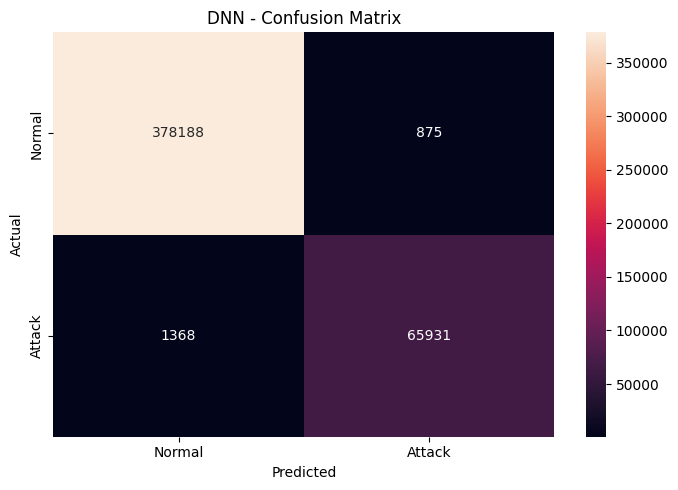

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_dnn)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DNN - Confusion Matrix')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob_dnn)
pr_auc = average_precision_score(y_test, y_prob_dnn)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9995
PR-AUC: 0.9978


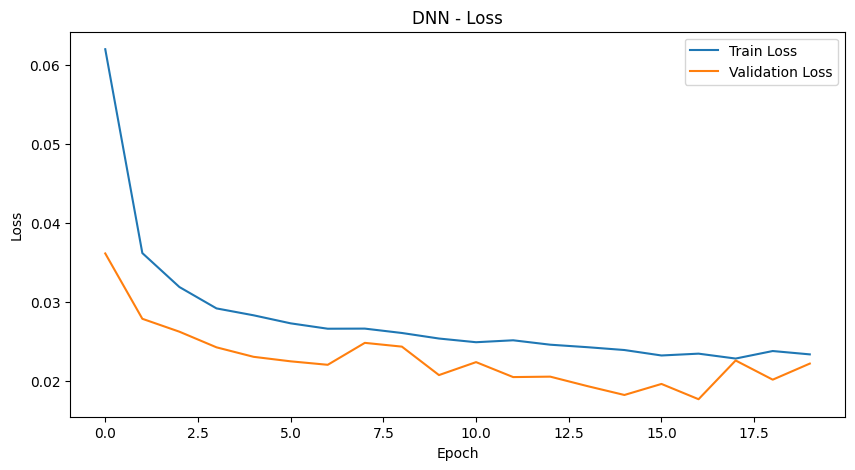

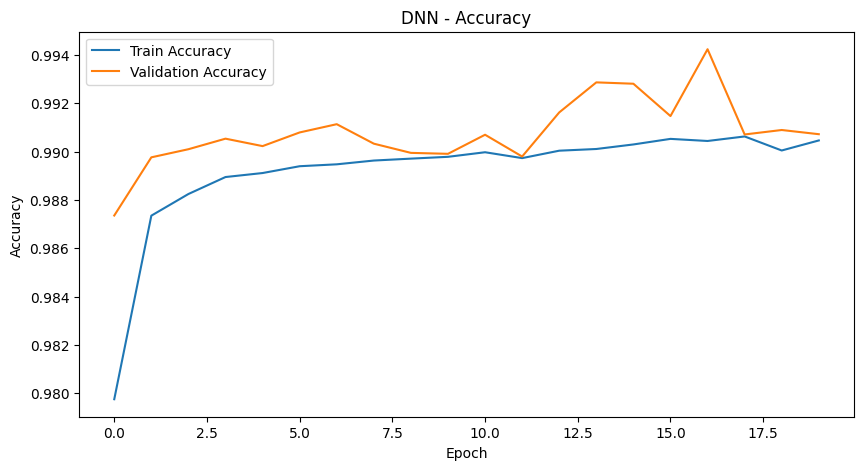

In [19]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Loss
plt.figure(figsize=(10, 5))

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DNN - Loss')
plt.legend()
plt.show()


# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DNN - Accuracy')
plt.legend()
plt.show()

# Autoencoder (detecção de anomalias / zero-day)

In [20]:
# Separar apenas o tráfego NORMAL do conjunto de treino
# O Autoencoder aprende a reconstruir o padrão "normal"; por isso não usa nem vê ataques no treino.

X_train_normal = X_train_scaled[y_train.values == 0]

print(f"Registros normais disponíveis para treinar o Autoencoder: {X_train_normal.shape[0]:,}")

# Separar uma fatia de validação (também só normal) para calibrar o threshold depois
from sklearn.model_selection import train_test_split as train_test_split_ae

X_train_ae, X_val_ae = train_test_split_ae(
    X_train_normal,
    test_size=0.1,
    random_state=42
)

print(f"Treino AE: {X_train_ae.shape[0]:,}")
print(f"Validação AE: {X_val_ae.shape[0]:,}")

Registros normais disponíveis para treinar o Autoencoder: 1,516,251
Treino AE: 1,364,625
Validação AE: 151,626


In [21]:
# Arquitetura do Autoencoder
# Ativação linear na camada de saída (não sigmoid!): como os dados usam StandardScaler,
# os valores podem ser negativos e maiores que 1, e o sigmoid não conseguiria reconstruí-los.

input_dim_ae = X_train_ae.shape[1]

encoder_input = keras.Input(shape=(input_dim_ae,))
encoded = layers.Dense(64, activation="relu")(encoder_input)
encoded = layers.Dense(32, activation="relu")(encoded)
encoded = layers.Dense(16, activation="relu", name="bottleneck")(encoded)

decoded = layers.Dense(32, activation="relu")(encoded)
decoded = layers.Dense(64, activation="relu")(decoded)
decoded = layers.Dense(input_dim_ae, activation="linear")(decoded)

model_ae = keras.Model(encoder_input, decoded, name="autoencoder")

model_ae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model_ae.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 56)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 56)             │         3,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,552 (49.03 KB)

 Trainable params: 12,552 (49.03 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Treinamento do Autoencoder
# Repare: X e y do fit são os MESMOS dados (X_train_ae) — o autoencoder aprende a
# reconstruir a própria entrada, por isso não usa a coluna Label aqui.

callbacks_ae = [
    EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    )
]

history_ae = model_ae.fit(
    X_train_ae, X_train_ae,
    epochs=50,
    batch_size=1024,
    validation_data=(X_val_ae, X_val_ae),
    callbacks=callbacks_ae,
    shuffle=True,
    verbose=1
)

Epoch 1/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.2467 - val_loss: 0.1200 - learning_rate: 0.0010
Epoch 2/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.1260 - val_loss: 0.0814 - learning_rate: 0.0010
Epoch 3/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.0961 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 4/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0796 - val_loss: 0.0452 - learning_rate: 0.0010
Epoch 5/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0719 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 6/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0736 - val_loss: 0.0569 - learning_rate: 0.0010
Epoch 7/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.0626 - val_loss: 0.0269 - learning_rate: 0.0010
Epoch 8/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.0476 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 9/50
1333/1333 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 0.0450 - val_loss: 0.051

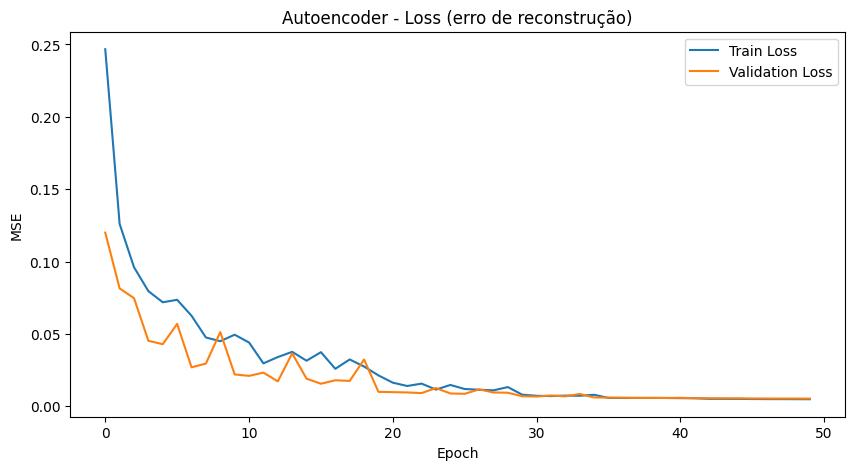

In [23]:
# Loss do Autoencoder (treino x validação)

plt.figure(figsize=(10, 5))
plt.plot(history_ae.history['loss'], label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Autoencoder - Loss (erro de reconstrução)')
plt.legend()
plt.show()

In [24]:
# Definir o threshold (99) a partir do erro de reconstrução SÓ em dados normais de validação
X_val_ae_pred = model_ae.predict(X_val_ae)
val_mse = np.mean(np.power(X_val_ae - X_val_ae_pred, 2), axis=1)

threshold_ae = np.percentile(val_mse, 99)
print(f"Threshold do Autoencoder (99, calibrado em validação normal): {threshold_ae:.4f}")

# Aplicar o Autoencoder no conjunto de TESTE completo (Normal + Attack)
X_test_ae_pred = model_ae.predict(X_test_scaled)
test_mse = np.mean(np.power(X_test_scaled - X_test_ae_pred, 2), axis=1)

y_pred_ae = (test_mse > threshold_ae).astype(int)

print("\nClassification Report - Autoencoder:\n")
print(
    classification_report(
        y_test,
        y_pred_ae,
        target_names=['Normal', 'Attack']
    )
)

roc_auc_ae = roc_auc_score(y_test, test_mse)
print(f"ROC-AUC (usando o erro de reconstrução como score): {roc_auc_ae:.4f}")

4739/4739 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Threshold do Autoencoder (99, calibrado em validação normal): 0.0687
13949/13949 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step

Classification Report - Autoencoder:

              precision    recall  f1-score   support

      Normal       0.94      0.99      0.97    379063
      Attack       0.92      0.66      0.77     67299

    accuracy                           0.94    446362
   macro avg       0.93      0.83      0.87    446362
weighted avg       0.94      0.94      0.94    446362

ROC-AUC (usando o erro de reconstrução como score): 0.9364


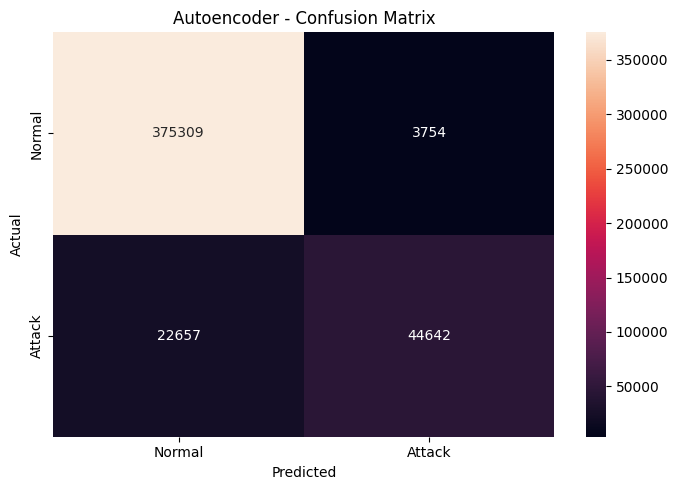

In [25]:
# Matriz de confusão - Autoencoder

cm_ae = confusion_matrix(y_test, y_pred_ae)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_ae,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Autoencoder - Confusion Matrix')
plt.tight_layout()
plt.show()

# Cascata: DNN → Autoencoder

In [26]:
# Regra da cascata (Camada 1 de proteção):
# 1. Se o DNN classifica como Attack (1) -> bloqueio direto, decisão final = Attack.
# 2. Se o DNN classifica como Normal (0) -> o pacote passa pelo Autoencoder.
#    2a. Se o Autoencoder também diz Normal -> decisão final = Normal.
#    2b. Se o Autoencoder aponta anomalia -> esse é o grupo que, na prática,
#        seria escalado para investigação (ex.: agente Luna), aqui tratado como Attack
#        para fins de avaliação da cascata completa.

y_pred_cascade = y_pred_dnn.copy()

mask_dnn_normal = (y_pred_dnn == 0)
y_pred_cascade[mask_dnn_normal] = y_pred_ae[mask_dnn_normal]

print("\nClassification Report - Cascata DNN + Autoencoder:\n")
print(
    classification_report(
        y_test,
        y_pred_cascade,
        target_names=['Normal', 'Attack']
    )
)

n_escalados = np.sum((y_pred_dnn == 0) & (y_pred_ae == 1))
pct_escalados = n_escalados / len(y_pred_dnn) * 100
print(f"\nPacotes que seriam escalados para investigação (Luna): {n_escalados:,} ({pct_escalados:.2f}% do conjunto de teste)")


Classification Report - Cascata DNN + Autoencoder:

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    379063
      Attack       0.94      0.98      0.96     67299

    accuracy                           0.99    446362
   macro avg       0.97      0.98      0.97    446362
weighted avg       0.99      0.99      0.99    446362


Pacotes que seriam escalados para investigação (Luna): 3,679 (0.82% do conjunto de teste)


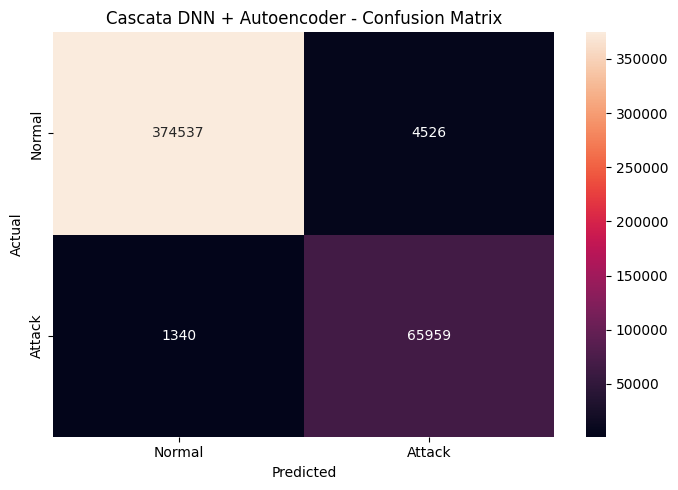

In [27]:
# Matriz de confusão - Cascata completa

cm_cascade = confusion_matrix(y_test, y_pred_cascade)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_cascade,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Cascata DNN + Autoencoder - Confusion Matrix')
plt.tight_layout()
plt.show()